# Lab #9: Measurement Study
## Comparing Height Estimation Methods

### Background

With the growing focus on the influence of healthy lifestyles on health outcomes, it is increasingly important to have measures of **body mass index (BMI)** available electronically for clinical decision support systems. BMI is computed from both height and weight, measured in a clinic.

**The Problem:** While weight is commonly collected and updated because it has historically been related to health, fewer patients have measures of height recorded electronically.

**The Solution:** To improve availability of height measures, two alternate physiologic measures have been proposed that may be easier to collect than direct height measurement:

1. **Forearm Length**
2. **Head Circumference**

### The Two Estimation Methods

#### Method 1: Forearm Length
- **Measurement**: Distance in inches from an individual's extended middle fingertip to the elbow
- **Technique**: Best measured with an extended hand and bent elbow, measured along the base of the arm
- **Height Estimation Formula**: $\text{Height}_{forearm} = 75.5 \text{ cm} + 3.48x$ (where x = forearm length in inches)

#### Method 2: Head Circumference
- **Measurement**: Circumference around the largest part of the head, at the height of the eyebrow and just above the top of the ears
- **Height Estimation Formula**: $\text{Height}_{head} = 3.17x$ (where x = head circumference in cm)

### Study Tasks

1. **Task 1 (Pearson's Correlation)**: Perform a measurement study for each alternative height measure and identify which is best correlated with actual height. Complete a correlation matrix and compute Pearson's r (after checking values are normally distributed).

2. **Task 2 (Kendall's Tau)**: Perform the same analysis, but represent each measure by the relative rank of individuals. Create correlation matrices and compute Kendall's Tau for each measure.

---
## Load and Prepare the Data

In [1]:
# Load the height estimates data
data <- read.csv("heightEstimates.csv")

# Display the raw data
cat("Raw Measurements Collected:\n")
print(data)
cat("\nNumber of participants:", nrow(data))

Raw Measurements Collected:
      Person height forearm head
1      Mindy  165.0      26   55
2  gabrielle  173.0      28   55
3      kenny  180.0      28   62
4      avery  167.0      25   60
5      ayana  153.0      26   57
6        cat  153.0      23   56
7      jacob  160.0      27   57
8     Kaylin  159.0      26   57
9      Jenny  156.0      25   56
10     Yujie  164.0      28   59
11     Jared  185.4      31   57

Number of participants: 11

In [2]:
# Apply the height estimation formulas
# Forearm method: Height = 75.5 cm + 3.48 * forearm_length_inches
# Head method: Height = 3.17 * head_circumference_cm

data$height_est_forearm <- 75.5 + 3.48 * data$forearm
data$height_est_head <- 3.17 * data$head

cat("Data with Estimated Heights:\n")
print(data[, c("Person", "height", "forearm", "height_est_forearm", "head", "height_est_head")])

Data with Estimated Heights:
      Person height forearm height_est_forearm head height_est_head
1      Mindy  165.0      26             165.98   55          174.35
2  gabrielle  173.0      28             172.94   55          174.35
3      kenny  180.0      28             172.94   62          196.54
4      avery  167.0      25             162.50   60          190.20
5      ayana  153.0      26             165.98   57          180.69
6        cat  153.0      23             155.54   56          177.52
7      jacob  160.0      27             169.46   57          180.69
8     Kaylin  159.0      26             165.98   57          180.69
9      Jenny  156.0      25             162.50   56          177.52
10     Yujie  164.0      28             172.94   59          187.03
11     Jared  185.4      31             183.38   57          180.69


In [3]:
# Summary statistics for actual height and both estimates
cat("Summary Statistics:\n\n")
summary(data[, c("height", "height_est_forearm", "height_est_head")])

Summary Statistics:



     height      height_est_forearm height_est_head
 Min.   :153.0   Min.   :155.5      Min.   :174.3  
 1st Qu.:157.5   1st Qu.:164.2      1st Qu.:177.5  
 Median :164.0   Median :166.0      Median :180.7  
 Mean   :165.0   Mean   :168.2      Mean   :181.8  
 3rd Qu.:170.0   3rd Qu.:172.9      3rd Qu.:183.9  
 Max.   :185.4   Max.   :183.4      Max.   :196.5  

---
## Task 1: Pearson's Correlation on Continuous Data

**Pearson's correlation coefficient (r)** measures the strength and direction of the **linear relationship** between two continuous variables.

- Values range from -1 to +1
- +1 = perfect positive linear correlation
- 0 = no linear correlation  
- -1 = perfect negative linear correlation

**Assumption**: Pearson's correlation assumes the data are approximately normally distributed. We should check this assumption first.

### Step 1.1: Check Normality of the Data

We use the **Shapiro-Wilk test** to assess normality. If p > 0.05, we fail to reject the null hypothesis that the data are normally distributed.

In [4]:
# Shapiro-Wilk test for normality
cat("=== Shapiro-Wilk Normality Tests ===\n\n")

shapiro_height <- shapiro.test(data$height)
cat("Actual Height: W =", round(shapiro_height$statistic, 4), 
    ", p =", round(shapiro_height$p.value, 4), "\n")

shapiro_forearm <- shapiro.test(data$height_est_forearm)
cat("Forearm Estimate: W =", round(shapiro_forearm$statistic, 4), 
    ", p =", round(shapiro_forearm$p.value, 4), "\n")

shapiro_head <- shapiro.test(data$height_est_head)
cat("Head Estimate: W =", round(shapiro_head$statistic, 4), 
    ", p =", round(shapiro_head$p.value, 4), "\n")

cat("\nInterpretation: p > 0.05 suggests data are approximately normally distributed.\n")

=== Shapiro-Wilk Normality Tests ===

Actual Height: W = 0.9226 , p = 0.3407 
Forearm Estimate: W = 0.9511 , p = 0.6583 
Head Estimate: W = 0.8797 , p = 0.1032 

Interpretation: p > 0.05 suggests data are approximately normally distributed.


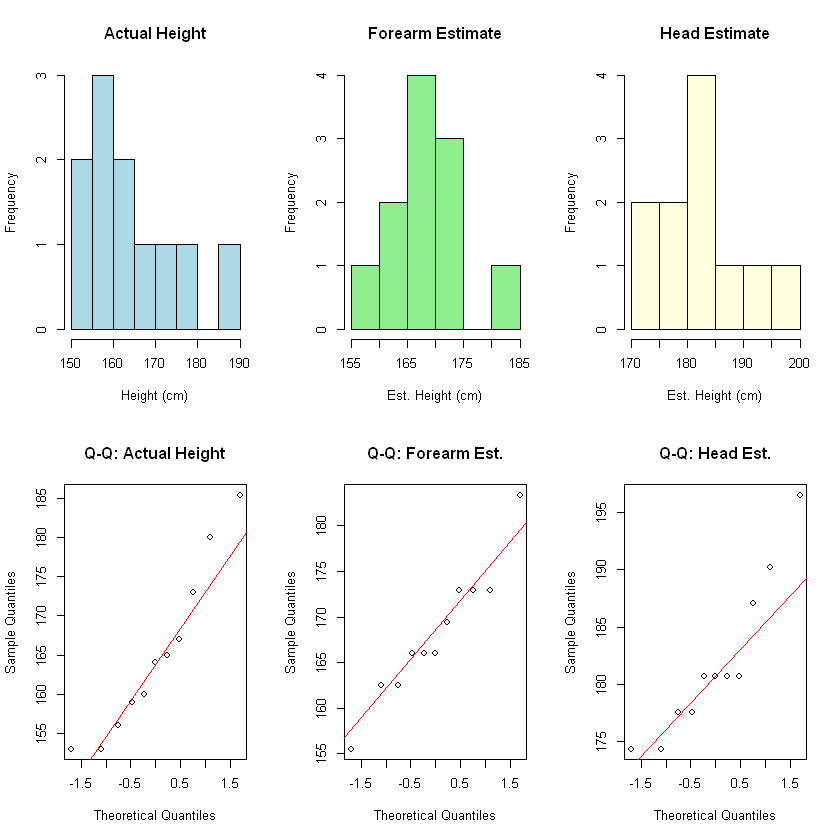

In [5]:
# Visual check for normality using histograms and Q-Q plots
par(mfrow = c(2, 3))

# Histograms
hist(data$height, main = "Actual Height", xlab = "Height (cm)", col = "lightblue")
hist(data$height_est_forearm, main = "Forearm Estimate", xlab = "Est. Height (cm)", col = "lightgreen")
hist(data$height_est_head, main = "Head Estimate", xlab = "Est. Height (cm)", col = "lightyellow")

# Q-Q plots
qqnorm(data$height, main = "Q-Q: Actual Height"); qqline(data$height, col = "red")
qqnorm(data$height_est_forearm, main = "Q-Q: Forearm Est."); qqline(data$height_est_forearm, col = "red")
qqnorm(data$height_est_head, main = "Q-Q: Head Est."); qqline(data$height_est_head, col = "red")

### Step 1.2: Correlation Matrix (Continuous Data)

A **correlation matrix** displays the pairwise Pearson correlation coefficients between all continuous variables. This gives us a quick overview of how strongly related our measurement methods are to each other and to the actual height.

**How to interpret the output:**

- **Values range from -1 to +1:**
  - **+1** = Perfect positive correlation (as one variable increases, the other increases proportionally)
  - **0** = No linear relationship
  - **-1** = Perfect negative correlation (as one variable increases, the other decreases)

- **Diagonal values** are always 1.0 (each variable is perfectly correlated with itself)

- **Off-diagonal values** show the correlation between different variables:
  - Values **> 0.7** suggest strong positive correlation
  - Values **0.4 - 0.7** suggest moderate correlation
  - Values **< 0.4** suggest weak correlation

- **For measurement validation**, we want to see high correlations (ideally > 0.8) between our estimation methods and the actual height, indicating that the methods are good predictors of true height.

- **Note:** Correlation only measures the *strength and direction* of a linear relationship—it does not tell us about accuracy or systematic bias. A method could be highly correlated with actual height but still consistently over- or under-estimate (which we'll assess with Bland-Altman analysis later).

In [9]:
# Create correlation matrix for continuous data
cor_matrix_pearson <- cor(data[, c("height", "height_est_forearm", "height_est_head")], 
                          method = "pearson")

cat("=== Pearson Correlation Matrix ===\n\n")
print(round(cor_matrix_pearson, 4))

=== Pearson Correlation Matrix ===

                   height height_est_forearm height_est_head
height             1.0000             0.8153          0.3640
height_est_forearm 0.8153             1.0000          0.1857
height_est_head    0.3640             0.1857          1.0000


### Step 1.3: Pearson's Correlation Tests

The `cor.test()` function provides a formal statistical test of correlation. Here's how to interpret each component of the output:

**Correlation Coefficient (r):**
- Measures the strength and direction of the linear relationship
- Ranges from -1 to +1 (same interpretation as the correlation matrix)
- **r²** (coefficient of determination) tells you the proportion of variance explained. For example, r = 0.9 means r² = 0.81, so 81% of the variance in actual height is explained by the estimation method.

**t-statistic:**
- Tests whether the correlation is significantly different from zero
- Larger absolute values indicate stronger evidence against the null hypothesis (that there is no correlation)
- Calculated as: $t = r \sqrt{\frac{n-2}{1-r^2}}$

**Degrees of Freedom (df):**
- Equal to n - 2 (sample size minus 2)
- Used to determine the critical value for the t-test

**p-value:**
- Tests the null hypothesis that the true correlation is zero (H₀: ρ = 0)
- **p < 0.05**: Statistically significant correlation (reject H₀)
- **p < 0.01**: Highly significant correlation
- **p < 0.001**: Very highly significant correlation
- A small p-value tells us the correlation is unlikely due to chance, but does NOT tell us about the magnitude or practical importance of the correlation

**95% Confidence Interval (CI):**
- Provides a range of plausible values for the true population correlation
- If the CI does not include 0, the correlation is statistically significant at α = 0.05
- **Narrower CI** = more precise estimate (typically from larger samples)
- **Wider CI** = less precise estimate
- Example interpretation: "We are 95% confident the true correlation lies between 0.75 and 0.92"

In [7]:
# Pearson's correlation: Forearm estimate vs Actual Height
cor_forearm <- cor.test(data$height_est_forearm, data$height, method = "pearson")

cat("=== Forearm Method vs Actual Height (Pearson's) ===\n")
cat("Correlation coefficient (r):", round(cor_forearm$estimate, 4), "\n")
cat("t-statistic:", round(cor_forearm$statistic, 4), "\n")
cat("Degrees of freedom:", cor_forearm$parameter, "\n")
cat("p-value:", format(cor_forearm$p.value, digits = 4), "\n")
cat("95% CI:", round(cor_forearm$conf.int[1], 4), "to", round(cor_forearm$conf.int[2], 4), "\n")

=== Forearm Method vs Actual Height (Pearson's) ===
Correlation coefficient (r): 0.8153 
t-statistic: 4.2246 
Degrees of freedom: 9 
p-value: 0.002224 
95% CI: 0.4217 to 0.9504 


In [8]:
# Pearson's correlation: Head estimate vs Actual Height
cor_head <- cor.test(data$height_est_head, data$height, method = "pearson")

cat("=== Head Method vs Actual Height (Pearson's) ===\n")
cat("Correlation coefficient (r):", round(cor_head$estimate, 4), "\n")
cat("t-statistic:", round(cor_head$statistic, 4), "\n")
cat("Degrees of freedom:", cor_head$parameter, "\n")
cat("p-value:", format(cor_head$p.value, digits = 4), "\n")
cat("95% CI:", round(cor_head$conf.int[1], 4), "to", round(cor_head$conf.int[2], 4), "\n")

=== Head Method vs Actual Height (Pearson's) ===
Correlation coefficient (r): 0.364 
t-statistic: 1.1725 
Degrees of freedom: 9 
p-value: 0.2711 
95% CI: -0.3018 to 0.7911 


In [10]:
# Summary comparison of Pearson correlations
cat("\n=== Task 1 Summary: Pearson Correlation Results ===\n\n")
cat("Forearm Method: r =", round(cor_forearm$estimate, 4), 
    "(p =", format(cor_forearm$p.value, digits = 3), ")\n")
cat("Head Method:    r =", round(cor_head$estimate, 4), 
    "(p =", format(cor_head$p.value, digits = 3), ")\n")


=== Task 1 Summary: Pearson Correlation Results ===

Forearm Method: r = 0.8153 (p = 0.00222 )
Head Method:    r = 0.364 (p = 0.271 )


---
## Task 2: Kendall's Tau Correlation on Ranked Data

**Kendall's Tau** is a non-parametric measure of correlation based on the concordance of ranked pairs. It measures how well the **rank ordering** is preserved between two variables.

- **Concordant pair**: Both variables rank a pair of observations in the same direction
- **Discordant pair**: Variables rank a pair of observations in opposite directions

$$\tau = \frac{(\text{concordant pairs}) - (\text{discordant pairs})}{\binom{n}{2}}$$

**Why use ranks?** Rank-based correlations are:
- Robust to outliers
- Do not assume normality
- Measure monotonic (not just linear) relationships

### Step 2.1: Convert Data to Ranks

In [11]:
# Create ranks for each variable (1 = smallest value)
data$rank_height <- rank(data$height)
data$rank_forearm <- rank(data$height_est_forearm)
data$rank_head <- rank(data$height_est_head)

# Display the ranked data
cat("=== Data with Ranks ===\n\n")
print(data[, c("Person", "height", "rank_height", 
               "height_est_forearm", "rank_forearm", 
               "height_est_head", "rank_head")])

=== Data with Ranks ===

      Person height rank_height height_est_forearm rank_forearm height_est_head
1      Mindy  165.0         7.0             165.98          5.0          174.35
2  gabrielle  173.0         9.0             172.94          9.0          174.35
3      kenny  180.0        10.0             172.94          9.0          196.54
4      avery  167.0         8.0             162.50          2.5          190.20
5      ayana  153.0         1.5             165.98          5.0          180.69
6        cat  153.0         1.5             155.54          1.0          177.52
7      jacob  160.0         5.0             169.46          7.0          180.69
8     Kaylin  159.0         4.0             165.98          5.0          180.69
9      Jenny  156.0         3.0             162.50          2.5          177.52
10     Yujie  164.0         6.0             172.94          9.0          187.03
11     Jared  185.4        11.0             183.38         11.0          180.69
   rank_head
1 

In [12]:
# Sort by actual height rank to compare orderings
data_sorted <- data[order(data$rank_height), ]

cat("=== Rank Comparison (Sorted by Actual Height) ===\n\n")
cat("If estimates perfectly preserve ordering, all columns would show 1,2,3,...\n\n")
print(data_sorted[, c("Person", "rank_height", "rank_forearm", "rank_head")])

=== Rank Comparison (Sorted by Actual Height) ===

If estimates perfectly preserve ordering, all columns would show 1,2,3,...

      Person rank_height rank_forearm rank_head
5      ayana         1.5          5.0       6.5
6        cat         1.5          1.0       3.5
9      Jenny         3.0          2.5       3.5
8     Kaylin         4.0          5.0       6.5
7      jacob         5.0          7.0       6.5
10     Yujie         6.0          9.0       9.0
1      Mindy         7.0          5.0       1.5
4      avery         8.0          2.5      10.0
2  gabrielle         9.0          9.0       1.5
3      kenny        10.0          9.0      11.0
11     Jared        11.0         11.0       6.5


### Step 2.2: Correlation Matrix (Ranked Data)

In [ ]:
# Create correlation matrix for ranked data using Kendall's tau
cor_matrix_kendall <- cor(data[, c("rank_height", "rank_forearm", "rank_head")], 
                          method = "kendall")

cat("=== Kendall's Tau Correlation Matrix (Ranked Data) ===\n\n")
print(round(cor_matrix_kendall, 4))

### Step 2.3: Kendall's Tau Correlation Tests

In [ ]:
# Kendall's tau: Forearm estimate vs Actual Height
tau_forearm <- cor.test(data$height_est_forearm, data$height, method = "kendall")

cat("=== Forearm Method vs Actual Height (Kendall's Tau) ===\n")
cat("Tau coefficient:", round(tau_forearm$estimate, 4), "\n")
cat("z-statistic:", round(tau_forearm$statistic, 4), "\n")
cat("p-value:", format(tau_forearm$p.value, digits = 4), "\n")

In [ ]:
# Kendall's tau: Head estimate vs Actual Height
tau_head <- cor.test(data$height_est_head, data$height, method = "kendall")

cat("=== Head Method vs Actual Height (Kendall's Tau) ===\n")
cat("Tau coefficient:", round(tau_head$estimate, 4), "\n")
cat("z-statistic:", round(tau_head$statistic, 4), "\n")
cat("p-value:", format(tau_head$p.value, digits = 4), "\n")

In [ ]:
# Summary comparison of Kendall's tau correlations
cat("\n=== Task 2 Summary: Kendall's Tau Results ===\n\n")
cat("Forearm Method: tau =", round(tau_forearm$estimate, 4), 
    "(p =", format(tau_forearm$p.value, digits = 3), ")\n")
cat("Head Method:    tau =", round(tau_head$estimate, 4), 
    "(p =", format(tau_head$p.value, digits = 3), ")\n")

---
## Summary: Comparing the Two Estimation Methods

In [ ]:
# Create comprehensive comparison table
comparison <- data.frame(
  Method = c("Forearm", "Head"),
  Formula = c("75.5 + 3.48x", "3.17x"),
  Pearson_r = c(round(cor_forearm$estimate, 4), round(cor_head$estimate, 4)),
  Pearson_p = c(round(cor_forearm$p.value, 4), round(cor_head$p.value, 4)),
  Kendall_tau = c(round(tau_forearm$estimate, 4), round(tau_head$estimate, 4)),
  Kendall_p = c(round(tau_forearm$p.value, 4), round(tau_head$p.value, 4))
)

cat("\n============================================================\n")
cat("     COMPARISON OF HEIGHT ESTIMATION METHODS\n")
cat("============================================================\n\n")
print(comparison, row.names = FALSE)

# Determine which method is better
cat("\n--- Findings ---\n\n")

better_pearson <- ifelse(abs(cor_forearm$estimate) > abs(cor_head$estimate), "Forearm", "Head")
better_kendall <- ifelse(abs(tau_forearm$estimate) > abs(tau_head$estimate), "Forearm", "Head")

cat("Based on Pearson's r (linear relationship):\n")
cat("  ->", better_pearson, "method shows stronger correlation with actual height\n\n")

cat("Based on Kendall's tau (rank ordering):\n")
cat("  ->", better_kendall, "method better preserves the relative ordering of heights\n")

---
## Visualizations

In [ ]:
# Scatter plots: Estimated Height vs Actual Height
par(mfrow = c(1, 2))

# Forearm method
plot(data$height_est_forearm, data$height, 
     main = paste("Forearm Method\nr =", round(cor_forearm$estimate, 3)),
     xlab = "Estimated Height from Forearm (cm)", 
     ylab = "Actual Height (cm)",
     pch = 19, col = "steelblue", cex = 1.5,
     xlim = c(min(data$height) - 10, max(data$height) + 10),
     ylim = c(min(data$height) - 10, max(data$height) + 10))
abline(lm(height ~ height_est_forearm, data = data), col = "red", lwd = 2)
abline(0, 1, col = "gray", lty = 2)  # Perfect agreement line
legend("bottomright", c("Regression", "Perfect agreement"), 
       col = c("red", "gray"), lty = c(1, 2), lwd = c(2, 1))

# Head method
plot(data$height_est_head, data$height,
     main = paste("Head Method\nr =", round(cor_head$estimate, 3)),
     xlab = "Estimated Height from Head (cm)",
     ylab = "Actual Height (cm)",
     pch = 19, col = "forestgreen", cex = 1.5,
     xlim = c(min(data$height) - 10, max(data$height) + 10),
     ylim = c(min(data$height) - 10, max(data$height) + 10))
abline(lm(height ~ height_est_head, data = data), col = "red", lwd = 2)
abline(0, 1, col = "gray", lty = 2)
legend("bottomright", c("Regression", "Perfect agreement"), 
       col = c("red", "gray"), lty = c(1, 2), lwd = c(2, 1))

In [ ]:
# Rank comparison plots
par(mfrow = c(1, 2))

# Forearm rank vs Height rank
plot(data$rank_forearm, data$rank_height,
     main = paste("Forearm Ranks\ntau =", round(tau_forearm$estimate, 3)),
     xlab = "Forearm Estimate Rank",
     ylab = "Actual Height Rank",
     pch = 19, col = "steelblue", cex = 1.5)
abline(0, 1, col = "gray", lty = 2, lwd = 2)  # Perfect agreement line
text(data$rank_forearm, data$rank_height, labels = data$Person, 
     pos = 3, cex = 0.7)

# Head rank vs Height rank
plot(data$rank_head, data$rank_height,
     main = paste("Head Ranks\ntau =", round(tau_head$estimate, 3)),
     xlab = "Head Estimate Rank",
     ylab = "Actual Height Rank",
     pch = 19, col = "forestgreen", cex = 1.5)
abline(0, 1, col = "gray", lty = 2, lwd = 2)
text(data$rank_head, data$rank_height, labels = data$Person, 
     pos = 3, cex = 0.7)

---
## Discussion Questions

1. **Which estimation method** (forearm or head) shows a stronger correlation with actual height? Is this consistent across both Pearson's r and Kendall's tau?

2. **Are the correlations statistically significant** (p < 0.05)? What does this mean for the clinical utility of these methods?

3. **Why might Pearson's r and Kendall's tau give different results?**
   - Pearson measures the strength of the *linear* relationship
   - Kendall measures whether *rank orderings* are preserved (monotonic relationship)
   - A method could have a strong monotonic relationship but not strictly linear

4. **What are the practical implications** for using these estimation methods in clinical settings to calculate BMI when direct height measurement is unavailable?

5. **What sources of measurement error** might affect each method? Consider:
   - Inter-rater reliability (different people measuring)
   - Positioning during measurement
   - Variations in body proportions across populations